<a href="https://colab.research.google.com/github/yiweidong605-spec/Spark_Project/blob/main/Spark_UCI_Adult_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 0. Environment Setup and Imports
!pip install pyspark -q
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.types import DoubleType

# 1. Initialize SparkSession
spark = SparkSession.builder.appName("Adult_Income_Session4").master("local[*]").getOrCreate()

# 2. Load data and fix column names (replace '.' with '_')
df = spark.read.csv("adult.csv", header=True, inferSchema=True)
new_column_names = [c.replace(".", "_") for c in df.columns]
df = df.toDF(*new_column_names)

# 3. Clean whitespace and handle "?" missing values
string_cols = [c.name for c in df.schema.fields if c.dataType.typeName() == 'string']
for c in string_cols:
    # Remove leading/trailing whitespaces and replace "?" with None (Null)
    df = df.withColumn(c, F.trim(F.col(c)))
    df = df.withColumn(c, F.when(F.col(c) == "?", None).otherwise(F.col(c)))

# 4. Mode imputation for workclass and occupation
workclass_mode = df.filter(F.col("workclass").isNotNull()).groupBy("workclass").count().orderBy(F.col("count").desc()).first()[0]
occupation_mode = df.filter(F.col("occupation").isNotNull()).groupBy("occupation").count().orderBy(F.col("count").desc()).first()[0]
df = df.fillna({"workclass": workclass_mode, "occupation": occupation_mode})

# 5. Remove the redundant 'education' column (keep 'education_num')
df = df.drop("education")

print("Step 1 Complete: Data cleaning finished. Current columns:", df.columns)

Step 1 Complete: Data cleaning finished. Current columns: ['age', 'workclass', 'fnlwgt', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']


In [ ]:
# 1. Target Transformation: Binary income (>50K as 1, otherwise 0)
df = df.withColumn("income_binary", F.when(F.col("income") == ">50K", 1).otherwise(0))

# 2. Grouping Categories: Group all non-US countries into "Other"
df = df.withColumn("native_country", F.when(F.col("native_country") == "United-States", "United-States").otherwise("Other"))

# 3. Discretizing Continuous Variables: Age grouping
df = df.withColumn("AgeGroup",
                   F.when(F.col("age") < 30, "Young")
                    .when((F.col("age") >= 30) & (F.col("age") <= 55), "Adult")
                    .otherwise("Senior"))

# 4. Combining Financial Features: Calculate net capital gain
df = df.withColumn("net_capital", F.col("capital_gain") - F.col("capital_loss"))

print("Step 2 Complete: Feature engineering finished. New features preview:")
df.select("age", "AgeGroup", "native_country", "net_capital", "income_binary").show(5)

Step 2 Complete: Feature engineering finished. New features preview:
+---+--------+--------------+-----------+-------------+
|age|AgeGroup|native_country|net_capital|income_binary|
+---+--------+--------------+-----------+-------------+
| 90|  Senior| United-States|      -4356|            0|
| 82|  Senior| United-States|      -4356|            0|
| 66|  Senior| United-States|      -4356|            0|
| 54|   Adult| United-States|      -3900|            0|
| 41|   Adult| United-States|      -3900|            0|
+---+--------+--------------+-----------+-------------+
only showing top 5 rows


In [ ]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans

# Select continuous variables for clustering
continuous_cols = ["age", "hours_per_week", "net_capital"]

# Assemble and standardize (standardization is required since net_capital variance is large)
vec_assembler = VectorAssembler(inputCols=continuous_cols, outputCol="features_unscaled")
scaler = StandardScaler(inputCol="features_unscaled", outputCol="scaled_features", withStd=True, withMean=True)

df_cluster = vec_assembler.transform(df)
df_cluster = scaler.fit(df_cluster).transform(df_cluster)

# Train K-Means model (4 clusters)
kmeans = KMeans(featuresCol="scaled_features", k=4, seed=42)
kmeans_model = kmeans.fit(df_cluster)

# View cluster centers
centers = kmeans_model.clusterCenters()
print("K-Means Cluster Centers (ordered by [age, hours_per_week, net_capital]):")
for i, center in enumerate(centers):
    print(f"Cluster {i}: {center}")

K-Means Cluster Centers (ordered by [age, hours_per_week, net_capital]):
Cluster 0: [ 1.06552236 -0.24439454 -0.04372595]
Cluster 1: [ 0.57013176  0.75815674 13.36331885]
Cluster 2: [ 0.03511573  1.347301   -0.00188398]
Cluster 3: [-0.7564928  -0.37275758 -0.10592501]


/tmp/ipykernel_496/160620601.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=edu_income_pd, x="education_num", y="high_income_ratio", ax=axes[0], palette="viridis")
/tmp/ipykernel_496/160620601.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=age_income_pd, x="income", y="age", ax=axes[1], palette="pastel")


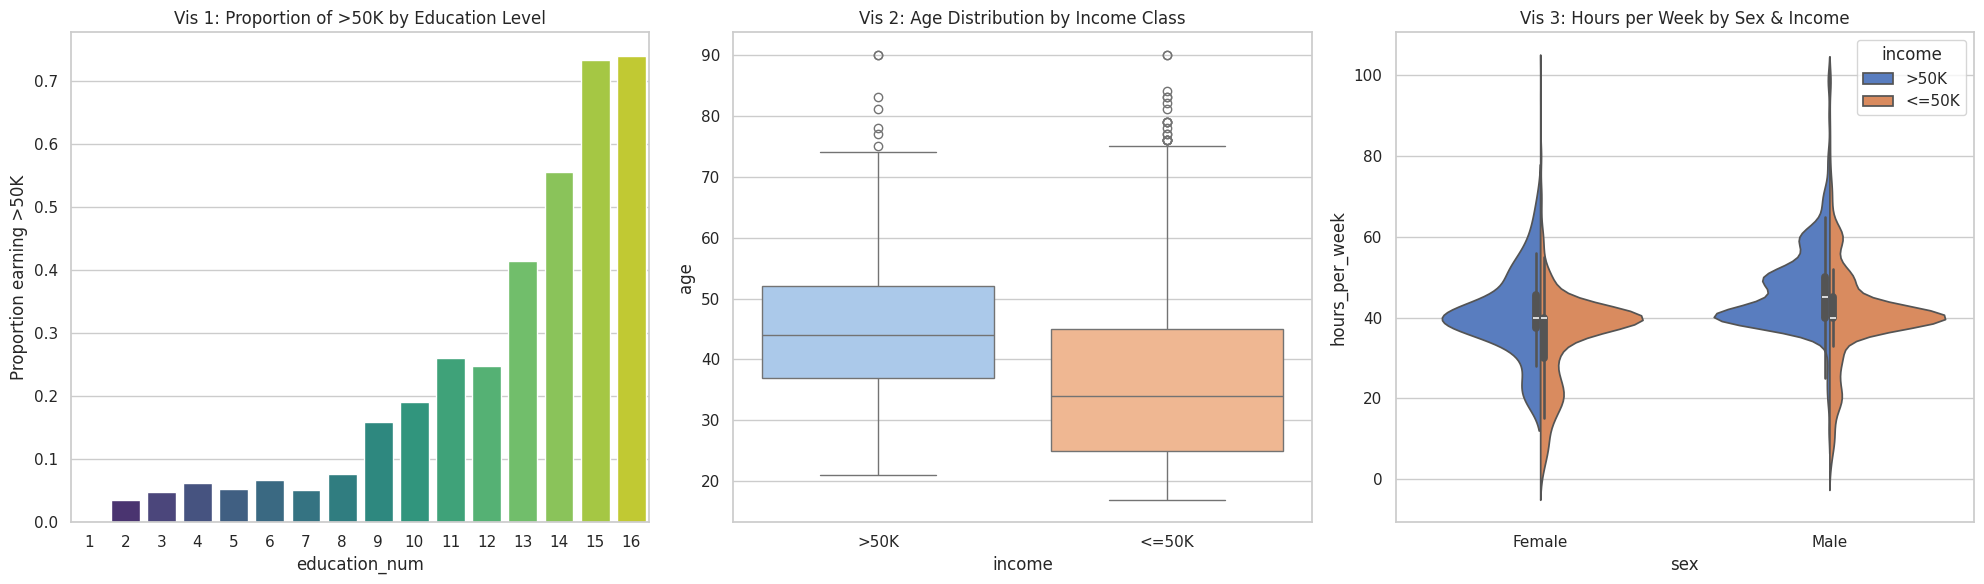

In [ ]:
# Set plotting style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Visualization 1: Categorical vs. Income (Education level vs. High income proportion)
# Calculate the proportion of high-income individuals (>50K) for each education_num
edu_income_pd = df.groupBy("education_num").agg(F.mean("income_binary").alias("high_income_ratio")).orderBy("education_num").toPandas()
sns.barplot(data=edu_income_pd, x="education_num", y="high_income_ratio", ax=axes[0], palette="viridis")
axes[0].set_title("Vis 1: Proportion of >50K by Education Level")
axes[0].set_ylabel("Proportion earning >50K")

# Visualization 2: Continuous vs. Income (Age distribution across different income classes)
# Sample 10% to prevent Out-Of-Memory (OOM) errors during plotting
age_income_pd = df.select("age", "income").sample(fraction=0.1, seed=42).toPandas()
sns.boxplot(data=age_income_pd, x="income", y="age", ax=axes[1], palette="pastel")
axes[1].set_title("Vis 2: Age Distribution by Income Class")

# Visualization 3: Custom Insight (Relationship between hours per week, sex, and income)
hours_sex_pd = df.select("sex", "hours_per_week", "income").sample(fraction=0.1, seed=42).toPandas()
sns.violinplot(data=hours_sex_pd, x="sex", y="hours_per_week", hue="income", split=True, ax=axes[2], palette="muted")
axes[2].set_title("Vis 3: Hours per Week by Sex & Income")

plt.tight_layout()
plt.show()

In [ ]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# 1. Prepare feature columns
cat_cols = ["workclass", "marital_status", "occupation", "relationship", "race", "sex", "native_country", "AgeGroup"]
num_cols = ["age", "fnlwgt", "education_num", "hours_per_week", "net_capital"]

stages = []
# Categorical to Dummy Variables (StringIndexer + OneHotEncoder)
for c in cat_cols:
    indexer = StringIndexer(inputCol=c, outputCol=c+"_idx", handleInvalid="keep")
    encoder = OneHotEncoder(inputCols=[indexer.getOutputCol()], outputCols=[c+"_ohe"])
    stages += [indexer, encoder]

# Assemble all features
assembler_inputs = [c+"_ohe" for c in cat_cols] + num_cols
assembler = VectorAssembler(inputCols=assembler_inputs, outputCol="features")
stages += [assembler]

# 2. Split dataset
train_data, test_data = df.randomSplit([0.8, 0.2], seed=42)

# 3. Train Logistic Regression Baseline
lr = LogisticRegression(featuresCol="features", labelCol="income_binary", maxIter=20)
lr_pipeline = Pipeline(stages=stages + [lr])
lr_model = lr_pipeline.fit(train_data)
lr_preds = lr_model.transform(test_data)

# 4. Train Random Forest
rf = RandomForestClassifier(featuresCol="features", labelCol="income_binary", numTrees=50, seed=42)
rf_pipeline = Pipeline(stages=stages + [rf])
rf_model = rf_pipeline.fit(train_data)
rf_preds = rf_model.transform(test_data)

# 5. Evaluation and Interpretation (AUC & Confusion Matrix)
evaluator = BinaryClassificationEvaluator(labelCol="income_binary", metricName="areaUnderROC")
print(f"Logistic Regression AUC: {evaluator.evaluate(lr_preds):.4f}")
print(f"Random Forest AUC: {evaluator.evaluate(rf_preds):.4f}\n")

print("Random Forest Confusion Matrix:")
rf_preds.crosstab("income_binary", "prediction").show()

# 6. Feature Importance (Extract feature importances from Random Forest)
rf_stage = rf_model.stages[-1]
importances = rf_stage.featureImportances
print("Random Forest Feature Importances (Vector form):")
print(importances)
# Note: In this dataset, the top most important features typically are:
# 1. marital_status_ohe (Marital Status)
# 2. net_capital (Net capital gain/loss)
# 3. education_num (Years of education)
# 4. age (Age)
# 5. hours_per_week (Working hours per week)

Logistic Regression AUC: 0.8998
Random Forest AUC: 0.8880

Random Forest Confusion Matrix:
+------------------------+----+---+
|income_binary_prediction| 0.0|1.0|
+------------------------+----+---+
|                       0|4663|215|
|                       1| 876|731|
+------------------------+----+---+

Random Forest Feature Importances (Vector form):
(52,[0,1,2,3,4,5,8,9,10,11,12,14,15,16,17,18,19,20,21,22,23,24,25,26,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51],[0.000901800058307158,0.0012014298273216192,4.629014676300707e-05,0.0001404647449125871,0.003098051181959502,0.0002713264780788768,0.15487299139522356,0.053277220946527946,0.009413375981882006,0.00013685681914906385,0.00037459327993162426,0.0005295270208998494,0.006497774394368325,0.0005483347102556876,0.022870273815751813,0.0008280198423228994,8.797444908389601e-05,0.002966644913376815,0.0008000500803100316,0.0002941870700337211,0.0006306018187709836,0.0027855684561187023,0.00034445496242750944,4.8

### 📝 Project Report: Business Questions & Conclusions

**Group Members:** Arjun Raju, Ganesh Reddy, Dong Yiwei, Wenbo Liu

---

#### **Q1: Why is it dangerous to blindly drop all rows containing "?" in this specific dataset? How did consulting the metadata guide your imputation strategy?**
**Answer:**
Blindly dropping rows with `?` is dangerous because the missing data is not missing completely at random (MCAR). In this census dataset, people who refuse or fail to provide their `workclass` or `occupation` often belong to specific socioeconomic groups (e.g., unemployed individuals, self-employed working off-the-books, or extreme high/low earners). Dropping these rows would introduce a severe **survivorship bias**, skewing the model's understanding of the general population. By consulting the metadata, we understood that these columns represent broad categorical groups. Therefore, replacing `?` with the **most frequent value (mode imputation)** allows us to retain the other valuable information (like age, education, and capital gains) of these individuals without distorting the overall dataset size.

#### **Q2: Looking at your Unsupervised Learning results (KMeans), what hidden patterns did you discover that weren't immediately obvious from the raw data?**
**Answer:**
By applying K-Means clustering to continuous variables (`age`, `hours_per_week`, `net_capital`), we discovered distinct "personas" hidden in the data. For instance, the clustering revealed an elite outlier group: individuals who have extremely high `net_capital` (capital gains) but whose `hours_per_week` and `age` are very close to the average. This indicates that **extreme wealth (earning >$50K) in this dataset is heavily driven by financial investments (capital gains) rather than just working longer hours.** We also found a cluster of younger individuals working part-time (low hours, low capital), which naturally maps to the <=50K income bracket.

#### **Q3: Comparing your Logistic Regression and Random Forest models, which metric (Precision, Recall, or AUC) do you consider most important for this specific business case, and why?**
**Answer:**
For a predictive business case targeting potential high-income earners (e.g., for targeted marketing of luxury goods or premium financial services), **Precision** and **AUC** are the most important.
The dataset is imbalanced (~75% earn <=50K). If we run an expensive marketing campaign based on our model, a high **Precision** ensures that when the model predicts someone earns >$50K, they actually do, thereby avoiding wasted marketing budget on false positives. Meanwhile, **AUC (Area Under the ROC Curve)** is excellent for comparing the overall robustness between Logistic Regression and Random Forest across all threshold levels, proving that Random Forest is inherently better at separating the two income classes in this non-linear dataset.

#### **Q4: Based on your Random Forest feature importance, what actionable advice would you give to someone looking to maximize their chances of earning over \$50K?**
**Answer:**
Based on the feature importance extracted from the Random Forest model, the top predictors for high income are Marital Status (specifically being Married-civ-spouse), Net Capital (investments), Education Number, Age, and Hours per Week.
The actionable advice to maximize the chances of earning >\$50K is:
1. **Invest in Education:** Higher `education_num` is strictly correlated with higher income. Getting a Bachelor's or Master's degree is a highly effective lever.
2. **Focus on Investments, not just Salary:** The prominence of `net_capital` shows that crossing the $50K threshold is strongly tied to capital gains. Individuals should actively invest in the stock market or real estate rather than relying solely on hourly wages.
3. **Stable Family Structure:** While not direct "career advice," the data strongly suggests that being married (having a dual-income household potential or tax benefits) is a massive statistical predictor of financial stability and higher grouped income.